### XGBoost (Extreme Gradient Boosting) is an optimized and scalable implementation of the gradient boosting framework designed for supervised learning tasks such as regression and classification. In regression, XGBoost aims to predict continuous numeric values by minimizing loss functions (e.g., RMSE or MSE) while incorporating regularisation to prevent overfitting.

### Use XGBoost in Regression
#### XGBoost is particularly effective for regression problems due to:

#### Handling Missing Values: Automatically handles missing data without requiring imputation.
#### Feature Importance: Provides insight into which features impact predictions.
#### Scalability: Efficient on large datasets with GPU acceleration.
#### Ensemble Learning: Combines multiple weak models to create a strong predictive model

### Importing libraries and Dataset
#### Here we will load seaborn and pandas library. We will use the mpg dataset from Seaborn to show the working.

In [2]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('mpg').dropna()

X = df.drop(columns=['mpg'])
y = df['mpg']

#### Data Preprocessing

In [3]:
X = pd.get_dummies(X, drop_first=True)

#### Splitting Data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Training XGBoost Regressor

In [6]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 2.967
R²: 0.834


####  Hyperparameter Tuning

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}


#### Feature Plotting

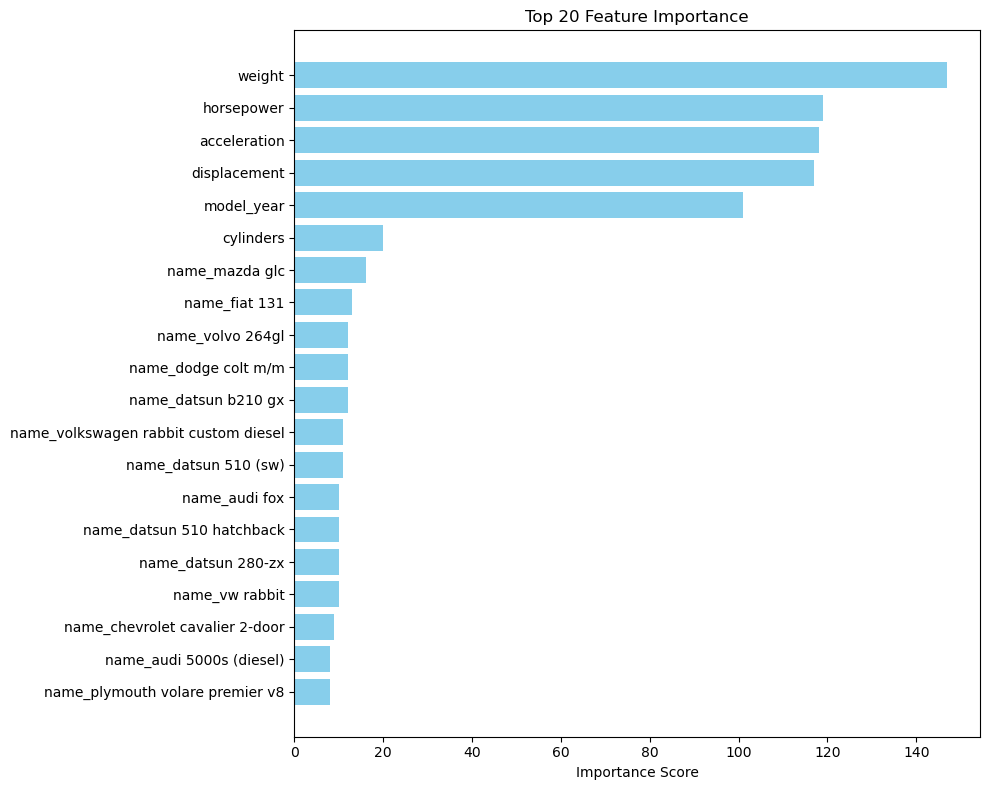

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()